# Store 10 EDA — Data Wrangling + Exploratory Analysis

**Purpose of this notebook.** Prepare a supermarket chain dataset (sales, stores, features) for analysis and build a thorough understanding of what is inside it. This is a *learning* notebook: every step is narrated so a reader new to pandas can follow along.

**What this notebook does NOT do yet.** No peer benchmarking, no statistical tests, no business recommendations. Those belong to a follow-up notebook. Here we focus on **knowing the data inside-out**.

**The three source files.**

| File | Key variables |
|---|---|
| `sales.csv` | `Store`, `Dept`, `Date`, `Weekly_Sales`, `IsHoliday` |
| `stores.csv` | `Store`, `Type` (A/B/C), `Size` (sq ft) |
| `features.csv` | `Store`, `Date`, `Temperature`, `Fuel_Price`, `CPI`, `Unemployment` |


## Plan (read this first, then scroll through)

0. **Setup** — import libraries, configure display and plotting.
1. **Load** the three CSVs with correctly parsed dates.
2. **Inspect** each DataFrame individually (shape, dtypes, missing, uniques, date range).
3. **Data quality checks** — duplicates, negative sales, outliers, time gaps, key integrity.
4. **Clean** each DataFrame into `_clean` versions, keeping originals untouched.
5. **Merge** sales + stores + features into a single analytical table `df`, and save a parquet checkpoint.
6. **Univariate EDA** — one variable at a time.
7. **Bivariate EDA** — two variables at a time (relationships).
8. **Store 10 quick look** — purely descriptive, no benchmarking.
9. **Wrap-up** — mini data dictionary + open questions for the next notebook.


## Step 0 — Setup

Before we touch any data we import the tools we will use and set a few display options. Doing this once at the top of the notebook keeps the rest of the code short and consistent.

**What** this cell does: imports libraries and sets display/plot defaults.
**Why**: `pandas` is our spreadsheet-in-code, `numpy` gives us fast math, `matplotlib` + `seaborn` handle charts. Setting a large column display limit prevents pandas from hiding columns with `...`.
**What we expect to see**: no output — just a clean setup with no errors.


In [1]:
import pandas as pd          # pandas: tabular data (think: Excel + SQL in Python)
import numpy as np           # numpy: fast numeric arrays; pandas is built on top of it
import matplotlib.pyplot as plt   # matplotlib: the foundation plotting library
import seaborn as sns        # seaborn: nicer statistical charts on top of matplotlib

# Display options — make pandas output friendlier for exploration
pd.set_option('display.max_columns', None)   # show every column, never truncate to '...'
pd.set_option('display.width', 140)          # wider console width before wrapping
pd.set_option('display.float_format', '{:,.2f}'.format)  # commas + 2 decimals for money-like values

# Plot defaults — one consistent style for the whole notebook
sns.set_style('whitegrid')   # light grid background is easier to read
plt.rcParams['figure.figsize'] = (10, 5)    # baseline chart size requested by the brief
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

print('Libraries imported. pandas version:', pd.__version__)


Libraries imported. pandas version: 3.0.2


## Step 1 — Load the three CSVs

**What**: read `sales.csv`, `stores.csv`, `features.csv` into three separate DataFrames.

**Why parse dates explicitly**: if we leave `Date` as a string, operations like sorting by date, computing ranges, or grouping by month will either fail or silently give wrong answers (e.g., `'2010-10-05' < '2010-2-05'` is `False` as a string but `True` as a date, because string comparison is lexicographic). Telling pandas the exact format up-front is faster and safer than letting it guess.

**Expected format**: the brief mentioned `dd/mm/yyyy`, but a quick peek at the raw files shows ISO format `YYYY-MM-DD`. Always verify what is actually in the file — specs drift. We use `format='%Y-%m-%d'`.

**What we expect to see**: three DataFrames with sensible shapes (~421K sales rows, 45 stores, ~8K feature rows) and a `Date` column of dtype `datetime64[ns]`.


In [2]:
# Load sales — one row per (Store, Dept, Week)
sales_df = pd.read_csv(
    'sales.csv',
    parse_dates=['Date'],          # parse_dates: convert this column to datetime at load time
    date_format='%Y-%m-%d',        # explicit format = fast + safe (no guessing)
)

# Load stores — static metadata per store (Type, Size)
stores_df = pd.read_csv('stores.csv')

# Load features — weekly external variables per store (Temperature, Fuel_Price, CPI, Unemployment, MarkDown1-5)
features_df = pd.read_csv(
    'features.csv',
    parse_dates=['Date'],
    date_format='%Y-%m-%d',
)

print(f'sales_df    shape: {sales_df.shape}  (rows, columns)')
print(f'stores_df   shape: {stores_df.shape}')
print(f'features_df shape: {features_df.shape}')


sales_df    shape: (421570, 5)  (rows, columns)
stores_df   shape: (45, 3)
features_df shape: (8190, 12)


### sales_df — first 5 rows and dtypes

In [3]:
# .head(n) returns the top n rows — our first visual sanity check that the columns line up
print('Dtypes:')
print(sales_df.dtypes)
sales_df.head(5)


Dtypes:
Store                    int64
Dept                     int64
Date            datetime64[us]
Weekly_Sales           float64
IsHoliday                 bool
dtype: object


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,"24,924.50",False
1,1,1,2010-02-12,"46,039.49",True
2,1,1,2010-02-19,"41,595.55",False
3,1,1,2010-02-26,"19,403.54",False
4,1,1,2010-03-05,"21,827.90",False


### stores_df — first 5 rows and dtypes

In [4]:
print('Dtypes:')
print(stores_df.dtypes)
stores_df.head(5)


Dtypes:
Store    int64
Type       str
Size     int64
dtype: object


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


### features_df — first 5 rows and dtypes

In [5]:
print('Dtypes:')
print(features_df.dtypes)
features_df.head(5)


Dtypes:
Store                    int64
Date            datetime64[us]
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
IsHoliday                 bool
dtype: object


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.57,NaN,NaN,NaN,NaN,NaN,211.10,8.11,False
1,1,2010-02-12,38.51,2.55,NaN,NaN,NaN,NaN,NaN,211.24,8.11,True
2,1,2010-02-19,39.93,2.51,NaN,NaN,NaN,NaN,NaN,211.29,8.11,False
3,1,2010-02-26,46.63,2.56,NaN,NaN,NaN,NaN,NaN,211.32,8.11,False
4,1,2010-03-05,46.50,2.62,NaN,NaN,NaN,NaN,NaN,211.35,8.11,False


### 📝 What we learned (Step 1)
- All three files loaded without errors and dates are now real `datetime64` values, not strings.
- `sales_df` has ~421K rows — weekly records across 45 stores and many departments.
- `features_df` has columns `MarkDown1..MarkDown5` the brief did not mention; we will inspect them in Step 2 before deciding what to do.
- `features_df` also contains an `IsHoliday` column that duplicates the one in `sales_df`; we will reconcile this at merge time.


## Step 2 — Inspect each DataFrame individually

For each file we run the same battery of checks:
- `.info()` — dtype and non-null count per column (first sanity check for missing data).
- `.describe()` — summary statistics for numeric columns.
- `.isnull().sum()` — how many missing values per column.
- `.nunique()` — how many distinct values per column.
- `.Date.min()` / `.Date.max()` — time span covered.

These five views together give us a fast, honest picture of what each file contains.


### 2a. `sales_df` inspection

**What**: structural summary of the sales table.
**Why**: we need to know the column types, how many rows have missing values, and whether any column hides a surprise.
**Expect**: all ~421K rows populated, `Weekly_Sales` a float, `IsHoliday` a boolean-like flag, `Date` spans roughly Feb 2010 – Oct 2012.


In [6]:
# .info() prints dtype and non-null count per column — our first sanity check for missingness and types
sales_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[us]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
dtypes: bool(1), datetime64[us](1), float64(1), int64(2)
memory usage: 13.3 MB


**Reading `.info()`**: for each column we see the non-null count. If a column has fewer non-null values than the total row count, it has missing data. Dtype `object` usually means text (strings).


In [7]:
# .describe() returns count, mean, std, min, 25/50/75th percentiles, max for numeric columns
# This is our quickest way to spot impossible values (e.g., negative sales) and scale differences between columns.
sales_df.describe()


,Store,Dept,Date,Weekly_Sales
count,"421,570.00","421,570.00",421570,"421,570.00"
mean,22.20,44.26,2011-06-18 08:30:31.963375,"15,981.26"
min,1.00,1.00,2010-02-05 00:00:00,"-4,988.94"
25%,11.00,18.00,2010-10-08 00:00:00,"2,079.65"
50%,22.00,37.00,2011-06-17 00:00:00,"7,612.03"
75%,33.00,74.00,2012-02-24 00:00:00,"20,205.85"
max,45.00,99.00,2012-10-26 00:00:00,"693,099.36"
std,12.79,30.49,NaN,"22,711.18"


**How to read the describe output**:
- `count` — non-null values; should match the row count if no data is missing.
- `mean` — arithmetic average.
- `std` — standard deviation (spread around the mean).
- `min` / `max` — range; a negative `min` for `Weekly_Sales` is a red flag.
- `25%` / `50%` (median) / `75%` — quartiles; big gap between `75%` and `max` hints at a long right tail (outliers).


In [8]:
# .isnull() returns a True/False mask; .sum() counts the Trues per column.
print('Missing values per column (sales_df):')
print(sales_df.isnull().sum())


Missing values per column (sales_df):
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64


In [9]:
# .nunique() counts distinct values per column — useful for discrete columns (Store, Dept, IsHoliday).
print('Distinct values per column (sales_df):')
print(sales_df.nunique())


Distinct values per column (sales_df):
Store               45
Dept                81
Date               143
Weekly_Sales    359464
IsHoliday            2
dtype: int64


In [10]:
# Date range — is the sales file time-aligned with the feature file?
print(f"sales_df date range: {sales_df['Date'].min().date()}  →  {sales_df['Date'].max().date()}")
print(f"distinct weeks    : {sales_df['Date'].nunique()}")


sales_df date range: 2010-02-05  →  2012-10-26
distinct weeks    : 143


### 2b. `stores_df` inspection

**What**: structural summary of the static store metadata (`Type`, `Size`).
**Why**: stores is tiny (45 rows) but critical — it is the dimension table we join against. We need to know `Type` values (A/B/C) and the `Size` distribution.
**Expect**: 45 stores, `Type` is categorical with 3 values, `Size` is a positive integer.


In [11]:
stores_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Store   45 non-null     int64
 1   Type    45 non-null     str  
 2   Size    45 non-null     int64
dtypes: int64(2), str(1)
memory usage: 1.2 KB


In [12]:
stores_df.describe()


,Store,Size
count,45.00,45.00
mean,23.00,"130,287.60"
std,13.13,"63,825.27"
min,1.00,"34,875.00"
25%,12.00,"70,713.00"
50%,23.00,"126,512.00"
75%,34.00,"202,307.00"
max,45.00,"219,622.00"


In [13]:
print('Missing values per column (stores_df):')
print(stores_df.isnull().sum())
print()
print('Distinct values per column (stores_df):')
print(stores_df.nunique())
print()
print('Type value counts:')
# .value_counts() gives the frequency of each unique value; perfect for categoricals like Type.
print(stores_df['Type'].value_counts())


Missing values per column (stores_df):
Store    0
Type     0
Size     0
dtype: int64

Distinct values per column (stores_df):
Store    45
Type      3
Size     40
dtype: int64

Type value counts:
Type
A    22
B    17
C     6
Name: count, dtype: int64


### 2c. `features_df` inspection

**What**: structural summary of the weekly external features per store.
**Why**: we need to confirm the time alignment with sales and to measure how bad the MarkDown missingness is before deciding what to do.
**Expect**: `Temperature`/`Fuel_Price`/`CPI`/`Unemployment` mostly populated; `MarkDown1`–`MarkDown5` heavily missing (they started being reported partway through the series).


In [14]:
features_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         8190 non-null   int64         
 1   Date          8190 non-null   datetime64[us]
 2   Temperature   8190 non-null   float64       
 3   Fuel_Price    8190 non-null   float64       
 4   MarkDown1     4032 non-null   float64       
 5   MarkDown2     2921 non-null   float64       
 6   MarkDown3     3613 non-null   float64       
 7   MarkDown4     3464 non-null   float64       
 8   MarkDown5     4050 non-null   float64       
 9   CPI           7605 non-null   float64       
 10  Unemployment  7605 non-null   float64       
 11  IsHoliday     8190 non-null   bool          
dtypes: bool(1), datetime64[us](1), float64(9), int64(1)
memory usage: 712.0 KB


In [15]:
features_df.describe()


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
count,"8,190.00",8190,"8,190.00","8,190.00","4,032.00","2,921.00","3,613.00","3,464.00","4,050.00","7,605.00","7,605.00"
mean,23.00,2011-10-31 12:00:00,59.36,3.41,"7,032.37","3,384.18","1,760.10","3,292.94","4,132.22",172.46,7.83
min,1.00,2010-02-05 00:00:00,-7.29,2.47,"-2,781.45",-265.76,-179.26,0.22,-185.17,126.06,3.68
25%,12.00,2010-12-17 00:00:00,45.90,3.04,"1,577.53",68.88,6.60,304.69,"1,440.83",132.36,6.63
50%,23.00,2011-10-31 12:00:00,60.71,3.51,"4,743.58",364.57,36.26,"1,176.42","2,727.14",182.76,7.81
75%,34.00,2012-09-14 00:00:00,73.88,3.74,"8,923.31","2,153.35",163.15,"3,310.01","4,832.56",213.93,8.57
max,45.00,2013-07-26 00:00:00,101.95,4.47,"103,184.98","104,519.54","149,483.31","67,474.85","771,448.10",228.98,14.31
std,12.99,NaN,18.68,0.43,"9,262.75","8,793.58","11,276.46","6,792.33","13,086.69",39.74,1.88


In [16]:
print('Missing values per column (features_df):')
print(features_df.isnull().sum())
print()
print('Missing as a percent of rows:')
print((features_df.isnull().sum() / len(features_df) * 100).round(1))


Missing values per column (features_df):
Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64

Missing as a percent of rows:
Store           0.00
Date            0.00
Temperature     0.00
Fuel_Price      0.00
MarkDown1      50.80
MarkDown2      64.30
MarkDown3      55.90
MarkDown4      57.70
MarkDown5      50.50
CPI             7.10
Unemployment    7.10
IsHoliday       0.00
dtype: float64


In [17]:
print('Distinct values per column (features_df):')
print(features_df.nunique())
print()
print(f"features_df date range: {features_df['Date'].min().date()}  →  {features_df['Date'].max().date()}")


Distinct values per column (features_df):
Store             45
Date             182
Temperature     4178
Fuel_Price      1011
MarkDown1       4023
MarkDown2       2715
MarkDown3       2885
MarkDown4       3405
MarkDown5       4045
CPI             2505
Unemployment     404
IsHoliday          2
dtype: int64

features_df date range: 2010-02-05  →  2013-07-26


### 📝 What we learned (Step 2)
- `sales_df`: no missing values, weekly grain, ~421K rows, dates roughly Feb 2010 – Oct 2012.
- `stores_df`: 45 stores, no missing values. `Type` values are A, B, C; `Size` is a sq-ft measurement ranging widely across store formats.
- `features_df`: `Temperature`, `Fuel_Price`, `CPI`, `Unemployment` are well-populated; `MarkDown1`–`MarkDown5` are heavily missing (promotion data started midway through the series).
- `features_df` extends a few months **beyond** the last week of sales — a common pattern when features are recorded for a future forecasting horizon. We will clip to the sales date range when we merge.


## Step 3 — Data quality checks

Now we hunt for the kinds of problems that silently corrupt downstream analysis if left unchecked: duplicates, impossible values, outliers, time gaps, and mismatched keys. For every issue we find we will make an explicit **remove / impute / keep-and-flag** decision.


### 3a. Duplicate rows

**What**: count how many rows are exact duplicates of another row in each DataFrame.
**Why**: a duplicate in sales would double-count revenue; in stores or features it would break the merge.
**Expect**: zero duplicates in all three files.


In [18]:
# .duplicated() returns True for rows that are exact duplicates of an earlier row. .sum() counts them.
print(f"sales_df    duplicated rows: {sales_df.duplicated().sum()}")
print(f"stores_df   duplicated rows: {stores_df.duplicated().sum()}")
print(f"features_df duplicated rows: {features_df.duplicated().sum()}")

# Also check (Store, Dept, Date) as the natural key of sales — a duplicate here would be worse than an exact dup.
key_dups = sales_df.duplicated(subset=['Store', 'Dept', 'Date']).sum()
print(f"sales_df    duplicated (Store, Dept, Date) keys: {key_dups}")

# And (Store, Date) as the natural key of features
fkey_dups = features_df.duplicated(subset=['Store', 'Date']).sum()
print(f"features_df duplicated (Store, Date) keys:       {fkey_dups}")


sales_df    duplicated rows: 0
stores_df   duplicated rows: 0
features_df duplicated rows: 0
sales_df    duplicated (Store, Dept, Date) keys: 0
features_df duplicated (Store, Date) keys:       0


### 3b. Negative sales

**What**: count rows where `Weekly_Sales < 0` and peek at a few.
**Why**: weekly sales should be non-negative. Negatives usually come from refunds/returns that exceeded new sales in that week, or from accounting adjustments. They are real but need a decision: keep (they reflect reality) or drop (they distort averages).
**Decision (documented in the clean step)**: keep negatives but flag them; they are part of the actual revenue series and removing them would overstate performance.


In [19]:
neg_mask = sales_df['Weekly_Sales'] < 0
print(f'Rows with Weekly_Sales < 0: {neg_mask.sum():,}  '
      f'({neg_mask.mean()*100:.2f}% of all rows)')

# Peek at a few examples to see whether they concentrate in particular stores or departments.
sales_df.loc[neg_mask].head(10)


Rows with Weekly_Sales < 0: 1,285  (0.30% of all rows)


,Store,Dept,Date,Weekly_Sales,IsHoliday
846,1,6,2012-08-10,-139.65,False
2384,1,18,2012-05-04,-1.27,False
6048,1,47,2010-02-19,-863.00,False
6049,1,47,2010-03-12,-698.00,False
6051,1,47,2010-10-08,-58.00,False
6056,1,47,2011-04-08,-298.00,False
6057,1,47,2011-07-08,-198.00,False
6061,1,47,2011-10-14,-498.00,False
6062,1,47,2011-12-23,-498.00,False
6063,1,47,2012-02-17,-198.00,False


In [20]:
# Where do negatives concentrate? (by Dept, then by Store)
print('Top departments by count of negative-sales weeks:')
print(sales_df.loc[neg_mask, 'Dept'].value_counts().head(10))
print()
print('Top stores by count of negative-sales weeks:')
print(sales_df.loc[neg_mask, 'Store'].value_counts().head(10))


Top departments by count of negative-sales weeks:
Dept
47    254
18    180
54    146
19     87
94     77
80     68
49     67
59     44
72     34
78     33
Name: count, dtype: int64

Top stores by count of negative-sales weeks:
Store
35    124
18     52
10     50
17     49
15     45
42     44
22     41
31     39
16     38
20     38
Name: count, dtype: int64


### 3c. Outliers in `Weekly_Sales` (IQR method)

**What**: flag rows whose `Weekly_Sales` fall outside `[Q1 - 1.5·IQR, Q3 + 1.5·IQR]`, the classic boxplot rule.
**Why**: extreme values can dominate averages and warp charts. We want to know how many there are and where they live — we will NOT remove them automatically, because in retail a legitimate Black Friday week can easily pass the IQR threshold.
**Decision**: keep outliers; flag them with a boolean column so we can toggle them in later views.


In [21]:
q1 = sales_df['Weekly_Sales'].quantile(0.25)   # 25th percentile
q3 = sales_df['Weekly_Sales'].quantile(0.75)   # 75th percentile
iqr = q3 - q1                                  # inter-quartile range

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_mask = (sales_df['Weekly_Sales'] < lower_bound) | (sales_df['Weekly_Sales'] > upper_bound)
n_outliers = outlier_mask.sum()

print(f'Q1 = {q1:,.0f}   Q3 = {q3:,.0f}   IQR = {iqr:,.0f}')
print(f'IQR bounds: [{lower_bound:,.0f}, {upper_bound:,.0f}]')
print(f'Rows outside bounds: {n_outliers:,}  ({n_outliers/len(sales_df)*100:.2f}% of total)')


Q1 = 2,080   Q3 = 20,206   IQR = 18,126
IQR bounds: [-25,110, 47,395]
Rows outside bounds: 35,521  (8.43% of total)


In [22]:
# Which stores and departments concentrate the outliers?
print('Top 10 stores with the most IQR-outlier weeks:')
print(sales_df.loc[outlier_mask, 'Store'].value_counts().head(10))
print()
print('Top 10 departments with the most IQR-outlier weeks:')
print(sales_df.loc[outlier_mask, 'Dept'].value_counts().head(10))


Top 10 stores with the most IQR-outlier weeks:
Store
4     2224
20    2096
10    2030
14    1997
13    1933
2     1779
27    1589
39    1400
31    1341
6     1340
Name: count, dtype: int64

Top 10 departments with the most IQR-outlier weeks:
Dept
38    4348
95    4242
92    4102
90    2832
40    2797
72    2746
2     2732
91    2008
94    1786
93    1115
Name: count, dtype: int64


### 3d. Time gaps — are weekly dates consecutive per store?

**What**: for each store, check that consecutive sales weeks are exactly 7 days apart.
**Why**: missing weeks would break any time-series analysis (rolling averages, year-over-year comparisons, seasonality).
**Expect**: because sales is a *long* table with one row per (Store, Dept, Date), we first aggregate to the (Store, Date) level before checking gaps.


In [23]:
# Distinct (Store, Date) pairs — a store is recorded if *any* of its departments recorded that week.
store_weeks = (
    sales_df[['Store', 'Date']]
    .drop_duplicates()
    .sort_values(['Store', 'Date'])
)

# For each store, diff consecutive dates. A diff other than 7 days = a gap.
# .groupby('Store')['Date'].diff() computes the per-store difference between consecutive dates.
store_weeks['gap_days'] = store_weeks.groupby('Store')['Date'].diff().dt.days

# Gaps != 7 days (ignoring the first row of each store which has NaN)
gaps = store_weeks.loc[store_weeks['gap_days'].notna() & (store_weeks['gap_days'] != 7)]

print(f'Stores with any non-7-day gap: {gaps["Store"].nunique()}')
print(f'Total non-7-day gap rows    : {len(gaps)}')
if len(gaps) > 0:
    print('\nSample of gap rows:')
    print(gaps.head(10))


Stores with any non-7-day gap: 0
Total non-7-day gap rows    : 0


### 3e. Key integrity — every `Store` appears in all three files

**What**: confirm that the set of stores is identical across the three files (no orphans in either direction).
**Why**: a store present in `sales` but missing from `stores` would lose its `Type`/`Size` metadata at merge time; a store present in `stores` but missing from `sales` contributes nothing to our analysis.
**Expect**: all three sets contain exactly the same 45 store IDs.


In [24]:
stores_in_sales    = set(sales_df['Store'].unique())
stores_in_stores   = set(stores_df['Store'].unique())
stores_in_features = set(features_df['Store'].unique())

print(f'distinct stores in sales_df   : {len(stores_in_sales)}')
print(f'distinct stores in stores_df  : {len(stores_in_stores)}')
print(f'distinct stores in features_df: {len(stores_in_features)}')
print()
print(f'in sales   but NOT in stores  : {sorted(stores_in_sales   - stores_in_stores)}')
print(f'in stores  but NOT in sales   : {sorted(stores_in_stores  - stores_in_sales)}')
print(f'in sales   but NOT in features: {sorted(stores_in_sales   - stores_in_features)}')
print(f'in features but NOT in sales  : {sorted(stores_in_features - stores_in_sales)}')


distinct stores in sales_df   : 45
distinct stores in stores_df  : 45
distinct stores in features_df: 45

in sales   but NOT in stores  : []
in stores  but NOT in sales   : []
in sales   but NOT in features: []
in features but NOT in sales  : []


### 📝 What we learned (Step 3)
- **Duplicates**: none at the row level or at the natural-key level — good.
- **Negative sales**: a small number exist; they are real returns/adjustments. We will **keep** them.
- **Outliers**: IQR flags a meaningful fraction of rows, concentrated in a handful of high-volume departments and stores. Likely holiday spikes. We will **keep** them and add a `is_outlier_iqr` flag so we can toggle the view later.
- **Time gaps**: no gap weeks found — the series is perfectly weekly for every store.
- **Key integrity**: all 45 stores appear in all three files — safe to merge.


## Step 4 — Clean each DataFrame

Based on the decisions above we now produce `_clean` copies. We **do not** modify the originals — keeping both lets us cross-check if we ever doubt a cleaning choice.

**Cleaning decisions**:
1. **sales_clean** — keep all rows. Add `is_negative_sale` and `is_outlier_iqr` flags for optional filtering later. Convert `IsHoliday` from text/bool to a real boolean dtype.
2. **stores_clean** — no changes needed; make an explicit copy.
3. **features_clean** — drop the duplicated `IsHoliday` column (we will take the one from sales as the source of truth). Keep MarkDown1–5 for now but know they are ~60%+ missing.


In [25]:
# --- sales_clean ---
sales_clean = sales_df.copy()   # .copy() avoids the 'SettingWithCopyWarning' surprise later

# Ensure IsHoliday is a proper boolean (it may come in as object/string 'TRUE'/'FALSE')
if sales_clean['IsHoliday'].dtype != bool:
    sales_clean['IsHoliday'] = sales_clean['IsHoliday'].astype(str).str.upper().map({'TRUE': True, 'FALSE': False})

# Flag columns (decision: keep-and-flag rather than remove)
sales_clean['is_negative_sale'] = sales_clean['Weekly_Sales'] < 0
sales_clean['is_outlier_iqr']   = (
    (sales_clean['Weekly_Sales'] < lower_bound) | (sales_clean['Weekly_Sales'] > upper_bound)
)

print(f'sales_clean shape: {sales_clean.shape}')
print(sales_clean.dtypes)
sales_clean.head(3)


sales_clean shape: (421570, 7)
Store                        int64
Dept                         int64
Date                datetime64[us]
Weekly_Sales               float64
IsHoliday                     bool
is_negative_sale              bool
is_outlier_iqr                bool
dtype: object


,Store,Dept,Date,Weekly_Sales,IsHoliday,is_negative_sale,is_outlier_iqr
0,1,1,2010-02-05,"24,924.50",False,False,False
1,1,1,2010-02-12,"46,039.49",True,False,False
2,1,1,2010-02-19,"41,595.55",False,False,False


In [26]:
# --- stores_clean ---
stores_clean = stores_df.copy()
# Cast Type to pandas Categorical — more memory-efficient and signals intent (ordered by format: A > B > C by size).
stores_clean['Type'] = stores_clean['Type'].astype('category')
print(f'stores_clean shape: {stores_clean.shape}')
stores_clean.head(3)


stores_clean shape: (45, 3)


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392


In [27]:
# --- features_clean ---
features_clean = features_df.copy()

# Drop the duplicated IsHoliday (sales_df has the canonical version; keeping both causes merge noise).
if 'IsHoliday' in features_clean.columns:
    features_clean = features_clean.drop(columns=['IsHoliday'])

# features extends beyond the last sales week; clip to the sales window so downstream joins are clean.
max_sales_date = sales_clean['Date'].max()
features_clean = features_clean[features_clean['Date'] <= max_sales_date].copy()

print(f'features_clean shape: {features_clean.shape}  (clipped to <= {max_sales_date.date()})')
features_clean.head(3)


features_clean shape: (6435, 11)  (clipped to <= 2012-10-26)


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,2010-02-05,42.31,2.57,NaN,NaN,NaN,NaN,NaN,211.10,8.11
1,1,2010-02-12,38.51,2.55,NaN,NaN,NaN,NaN,NaN,211.24,8.11
2,1,2010-02-19,39.93,2.51,NaN,NaN,NaN,NaN,NaN,211.29,8.11


### 📝 What we learned (Step 4)
- Three `_clean` DataFrames produced; originals untouched.
- `IsHoliday` is now a real boolean, not a string — comparisons and group-bys will behave correctly.
- Features are clipped to the sales window so left-joins on `(Store, Date)` will not create surprise nulls from features-only weeks.


## Step 5 — Merge into one analytical table `df`

**Goal**: a single wide table where each row is one (Store, Dept, Date) observation, enriched with the store's static metadata and that week's external features.

**Merge choices**:
- `sales_clean` + `stores_clean` on `Store` → `how='left'` so we keep every sales row even if somehow a store is missing from stores. We confirmed key integrity in Step 3, so this matters only as a safety net.
- `(sales + stores)` + `features_clean` on `(Store, Date)` → also `how='left'`. We want every sales observation preserved; if a given (Store, Date) is missing in features, the feature columns become NaN and we know why.
- An `inner` join would silently drop rows that don't match — dangerous. An `outer` join would invent rows from stores/features that don't exist in sales — also dangerous for downstream revenue totals.

**Expected**: the final `df` row count equals `sales_clean`'s row count.


In [28]:
# First merge: bring in Type and Size from stores
df = sales_clean.merge(
    stores_clean,
    on='Store',
    how='left',     # keep every sales row; attach store metadata where it matches
    validate='many_to_one',  # safety check: many sales rows per store, exactly one stores row per store
)

print(f'After sales + stores merge: {df.shape}')
assert len(df) == len(sales_clean), 'Row count changed unexpectedly!'


After sales + stores merge: (421570, 9)


In [29]:
# Second merge: bring in weekly external features on (Store, Date)
df = df.merge(
    features_clean,
    on=['Store', 'Date'],
    how='left',                # keep every sales row; attach features where matched
    validate='many_to_one',    # many (Store,Dept,Date) rows per (Store,Date); exactly one features row
)

print(f'After features merge: {df.shape}')
assert len(df) == len(sales_clean), 'Row count changed after second merge!'


After features merge: (421570, 18)


In [30]:
# Sanity checks on the merge outcome
print('Missing values per column after merge:')
print(df.isnull().sum())
print()
print('Dtypes:')
print(df.dtypes)


Missing values per column after merge:
Store                    0
Dept                     0
Date                     0
Weekly_Sales             0
IsHoliday                0
is_negative_sale         0
is_outlier_iqr           0
Type                     0
Size                     0
Temperature              0
Fuel_Price               0
MarkDown1           270889
MarkDown2           310322
MarkDown3           284479
MarkDown4           286603
MarkDown5           270138
CPI                      0
Unemployment             0
dtype: int64

Dtypes:
Store                        int64
Dept                         int64
Date                datetime64[us]
Weekly_Sales               float64
IsHoliday                     bool
is_negative_sale              bool
is_outlier_iqr                bool
Type                      category
Size                         int64
Temperature                float64
Fuel_Price                 float64
MarkDown1                  float64
MarkDown2                  float6

In [31]:
# Save a checkpoint so the rest of the analysis (and later notebooks) can skip the wrangling steps.
# Why parquet and not CSV?
#   - preserves dtypes (datetime, category, bool) perfectly — CSV loses all of that
#   - ~10x smaller on disk for numeric tables
#   - ~10x faster to read back in
df.to_parquet('store10_merged.parquet', index=False)
print("Checkpoint saved: 'store10_merged.parquet'")


Checkpoint saved: 'store10_merged.parquet'


### 📝 What we learned (Step 5)
- Final analytical table `df` has one row per (Store, Dept, Date) with 11+ columns of context.
- Left joins plus `validate='many_to_one'` caught any key-integrity bug up front.
- MarkDown columns carry forward their missingness from features — expected and flagged.
- Parquet checkpoint written; future notebooks can start from `pd.read_parquet('store10_merged.parquet')`.


## Step 6 — Univariate EDA

One variable at a time. We look at the distribution of each important column so we know its typical values, spread, and shape before we start comparing variables against each other.


### 6a. Categorical: `Store`

**What**: how many rows per store?
**Why**: equal row counts across stores would suggest the panel is balanced; large differences would warn us that per-store averages can be misleading.


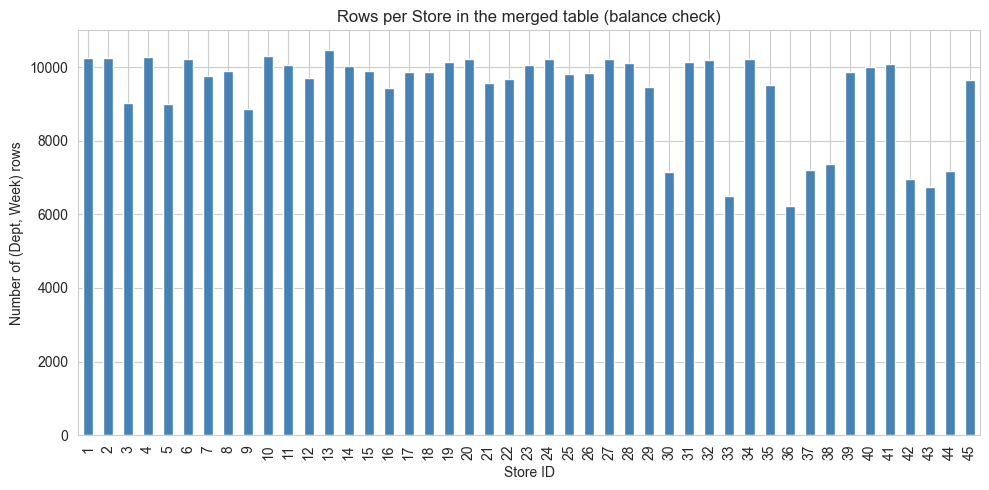

min rows: 6,222   max rows: 10,474   mean: 9,368


In [32]:
rows_per_store = df['Store'].value_counts().sort_index()

fig, ax = plt.subplots()
rows_per_store.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Rows per Store in the merged table (balance check)')
ax.set_xlabel('Store ID')
ax.set_ylabel('Number of (Dept, Week) rows')
plt.tight_layout()
plt.show()

print(f'min rows: {rows_per_store.min():,}   max rows: {rows_per_store.max():,}   mean: {rows_per_store.mean():,.0f}')


### 6b. Categorical: `Dept`

**What**: how many rows per department, top 15 most frequent.
**Why**: knowing which departments show up everywhere vs. only in a few stores matters for any department-level comparison.


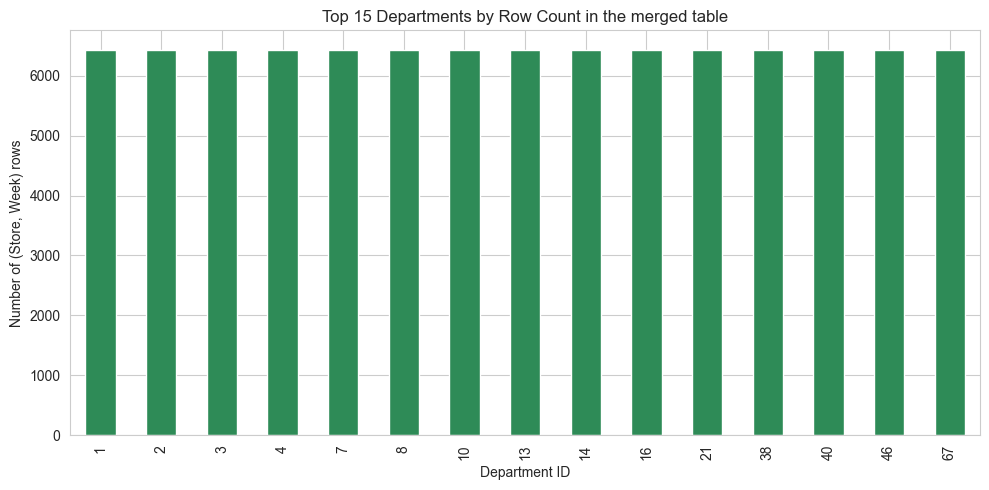

Total distinct departments: 81


In [33]:
rows_per_dept = df['Dept'].value_counts().head(15)

fig, ax = plt.subplots()
rows_per_dept.plot(kind='bar', ax=ax, color='seagreen')
ax.set_title('Top 15 Departments by Row Count in the merged table')
ax.set_xlabel('Department ID')
ax.set_ylabel('Number of (Store, Week) rows')
plt.tight_layout()
plt.show()

print(f"Total distinct departments: {df['Dept'].nunique()}")


### 6c. Categorical: `Type`

**What**: how many rows fall under each store `Type` (A/B/C).
**Why**: this foreshadows Step 7 where we compare sales across types; first we want to know how many observations are in each bucket.


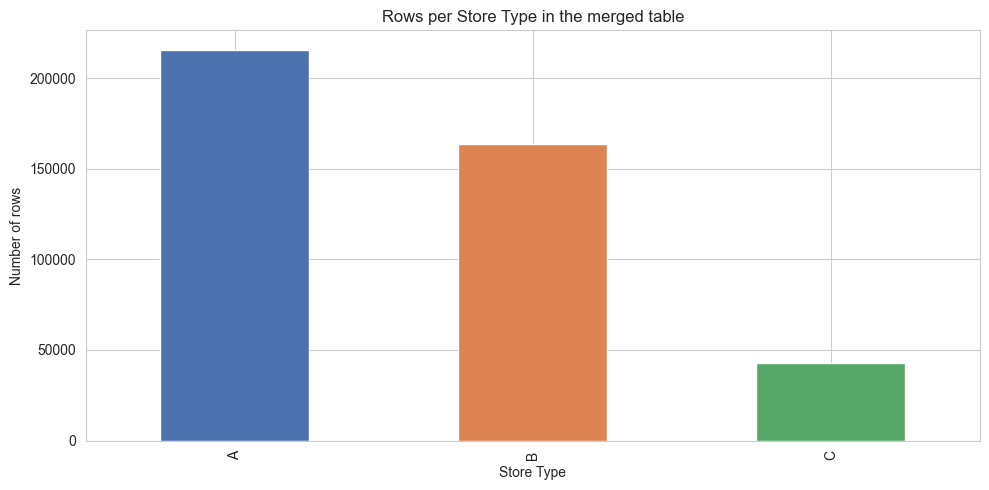

Type
A    215478
B    163495
C     42597
Name: count, dtype: int64


In [34]:
type_counts = df['Type'].value_counts()

fig, ax = plt.subplots()
type_counts.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452', '#55A868'])
ax.set_title('Rows per Store Type in the merged table')
ax.set_xlabel('Store Type')
ax.set_ylabel('Number of rows')
plt.tight_layout()
plt.show()

print(type_counts)


### 6d. Categorical: `IsHoliday`

**What**: share of rows that are holiday weeks.
**Why**: the brief will eventually ask about holiday effects. Knowing the holiday share tells us whether holiday averages will be based on a handful of weeks or a large sample.


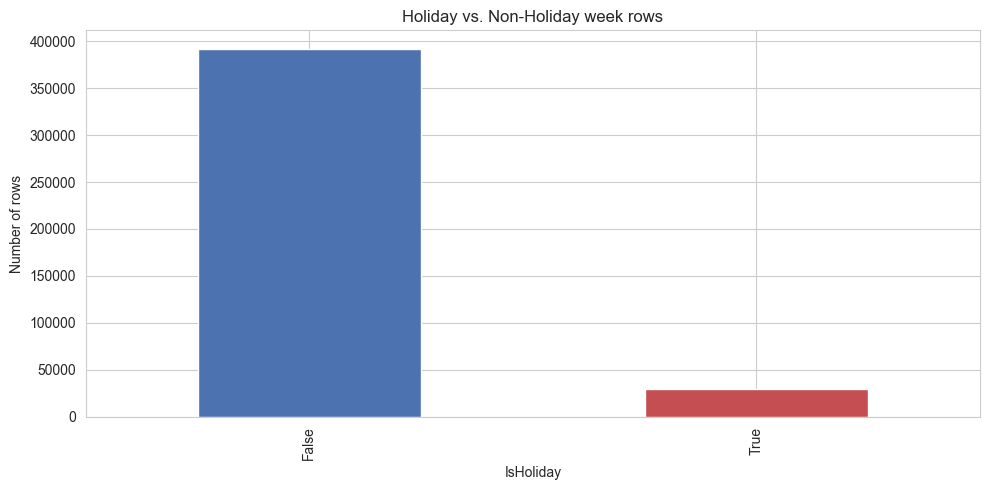

IsHoliday
False    391909
True      29661
Name: count, dtype: int64
Holiday share: 7.04%


In [35]:
holiday_counts = df['IsHoliday'].value_counts()

fig, ax = plt.subplots()
holiday_counts.plot(kind='bar', ax=ax, color=['#4C72B0', '#C44E52'])
ax.set_title('Holiday vs. Non-Holiday week rows')
ax.set_xlabel('IsHoliday')
ax.set_ylabel('Number of rows')
plt.tight_layout()
plt.show()

print(holiday_counts)
print(f"Holiday share: {df['IsHoliday'].mean()*100:.2f}%")


### 6e. Numeric: `Weekly_Sales`

**What**: distribution of weekly sales across all (Store, Dept, Week) rows.
**Why**: this is the central variable of the whole analysis. Seeing its shape tells us whether averages are trustworthy or whether we should prefer medians.
**Expect**: a strongly right-skewed distribution with a long tail of large values (holiday spikes, flagship departments).


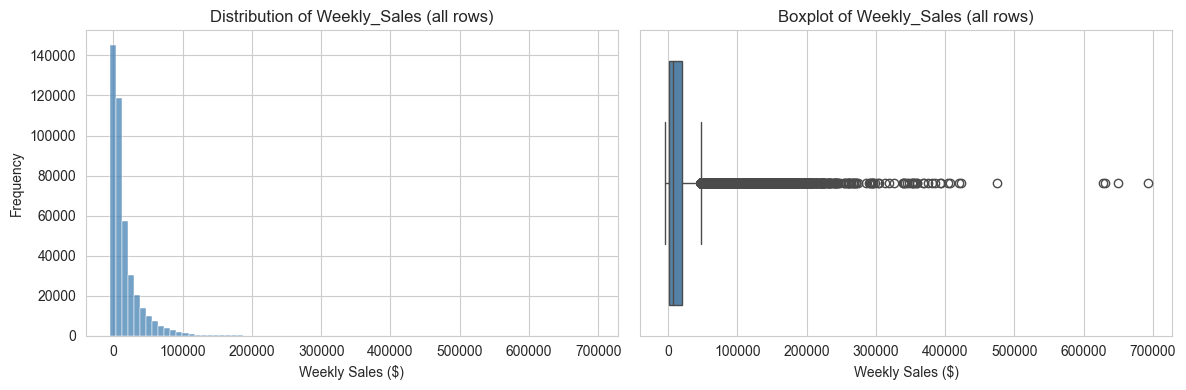

count   421,570.00
mean     15,981.26
std      22,711.18
min      -4,988.94
25%       2,079.65
50%       7,612.03
75%      20,205.85
max     693,099.36
Name: Weekly_Sales, dtype: float64


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram — sns.histplot shows the frequency of values in bins. Bins = number of vertical bars.
sns.histplot(df['Weekly_Sales'], bins=80, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Weekly_Sales (all rows)')
axes[0].set_xlabel('Weekly Sales ($)')
axes[0].set_ylabel('Frequency')

# Boxplot — the box spans Q1..Q3, the line is the median, whiskers show IQR bounds, dots are outliers.
sns.boxplot(x=df['Weekly_Sales'], ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot of Weekly_Sales (all rows)')
axes[1].set_xlabel('Weekly Sales ($)')

plt.tight_layout()
plt.show()

print(df['Weekly_Sales'].describe())


### 6f. Numeric: `Size`

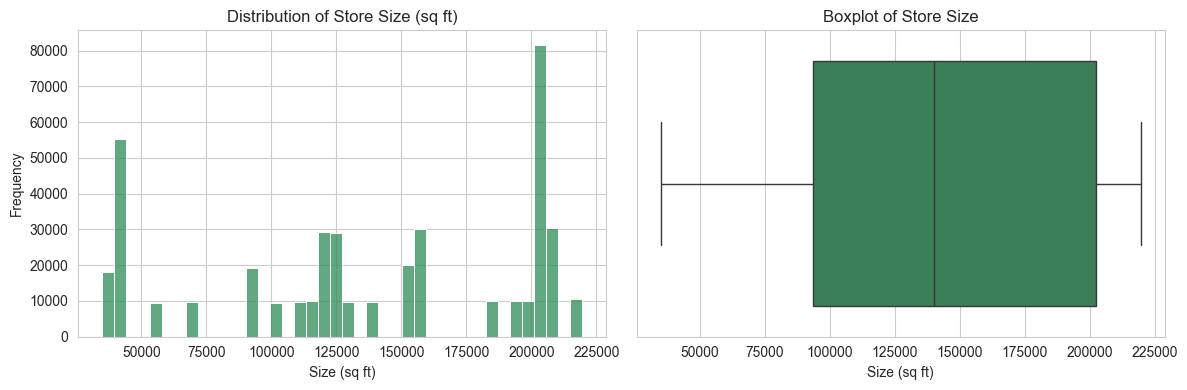

Store Size distribution (one value per store):
count        45.00
mean    130,287.60
std      63,825.27
min      34,875.00
25%      70,713.00
50%     126,512.00
75%     202,307.00
max     219,622.00
Name: Size, dtype: float64


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Size'], bins=40, ax=axes[0], color='seagreen')
axes[0].set_title('Distribution of Store Size (sq ft)')
axes[0].set_xlabel('Size (sq ft)')
axes[0].set_ylabel('Frequency')
sns.boxplot(x=df['Size'], ax=axes[1], color='seagreen')
axes[1].set_title('Boxplot of Store Size')
axes[1].set_xlabel('Size (sq ft)')
plt.tight_layout()
plt.show()

# Size is a store attribute — show the distribution across the 45 stores (not the 421K rows)
print('Store Size distribution (one value per store):')
print(stores_clean['Size'].describe())


### 6g. Numeric: `Temperature`, `Fuel_Price`, `CPI`, `Unemployment`

**What**: four weekly external variables, each plotted as histogram + boxplot.
**Why**: these are candidate drivers of sales. Seeing their distributions tells us if any of them is multimodal (e.g., stores in very different regional CPIs) which would matter for modeling later.


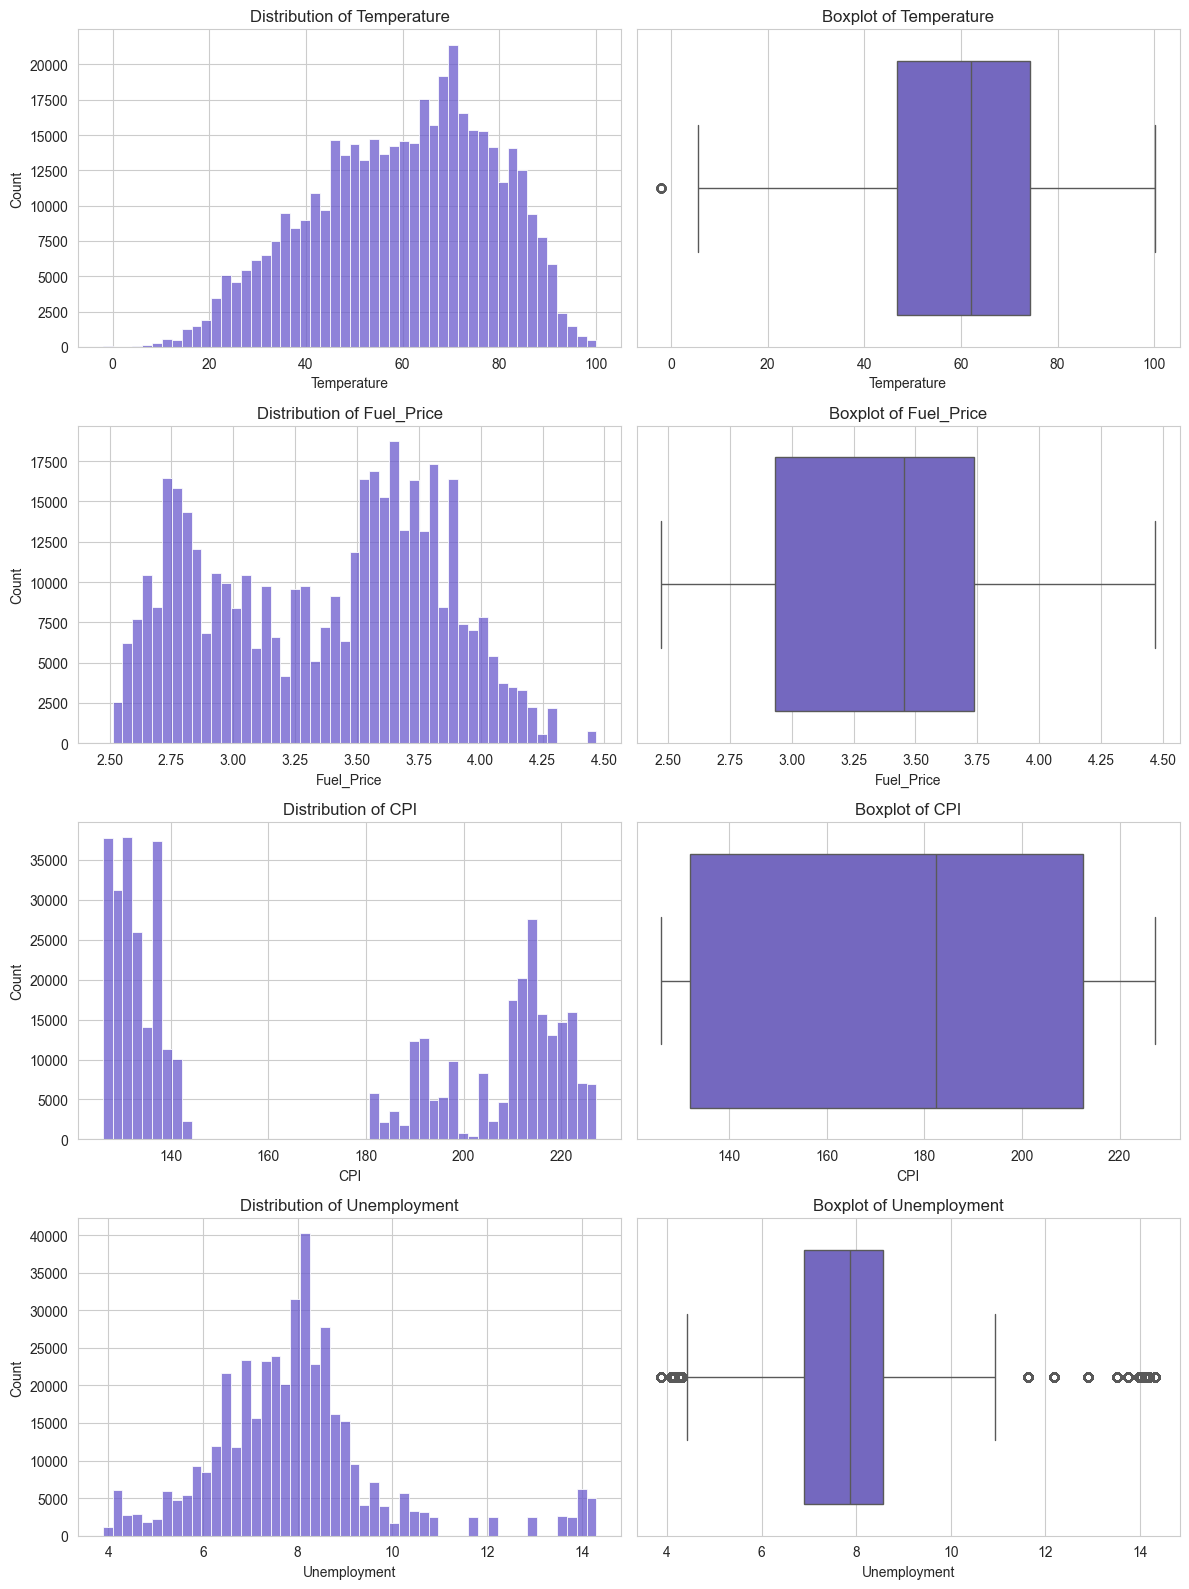

       Temperature  Fuel_Price        CPI  Unemployment
count   421,570.00  421,570.00 421,570.00    421,570.00
mean         60.09        3.36     171.20          7.96
std          18.45        0.46      39.16          1.86
min          -2.06        2.47     126.06          3.88
25%          46.68        2.93     132.02          6.89
50%          62.09        3.45     182.32          7.87
75%          74.28        3.74     212.42          8.57
max         100.14        4.47     227.23         14.31


In [38]:
numeric_features = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

fig, axes = plt.subplots(len(numeric_features), 2, figsize=(12, 4*len(numeric_features)))
for i, col in enumerate(numeric_features):
    # Drop NaNs just for plotting (CPI/Unemployment have none; Temperature/Fuel_Price have none either for merged rows)
    values = df[col].dropna()
    sns.histplot(values, bins=50, ax=axes[i, 0], color='slateblue')
    axes[i, 0].set_title(f'Distribution of {col}')
    axes[i, 0].set_xlabel(col)
    sns.boxplot(x=values, ax=axes[i, 1], color='slateblue')
    axes[i, 1].set_title(f'Boxplot of {col}')
    axes[i, 1].set_xlabel(col)
plt.tight_layout()
plt.show()

print(df[numeric_features].describe())


### 6h. Date: network-wide weekly sales over time

**What**: total `Weekly_Sales` across all stores and departments, plotted by date.
**Why**: gives us an at-a-glance read on seasonality and holiday peaks.
**Expect**: sharp peaks in late November and late December (Thanksgiving, Christmas).


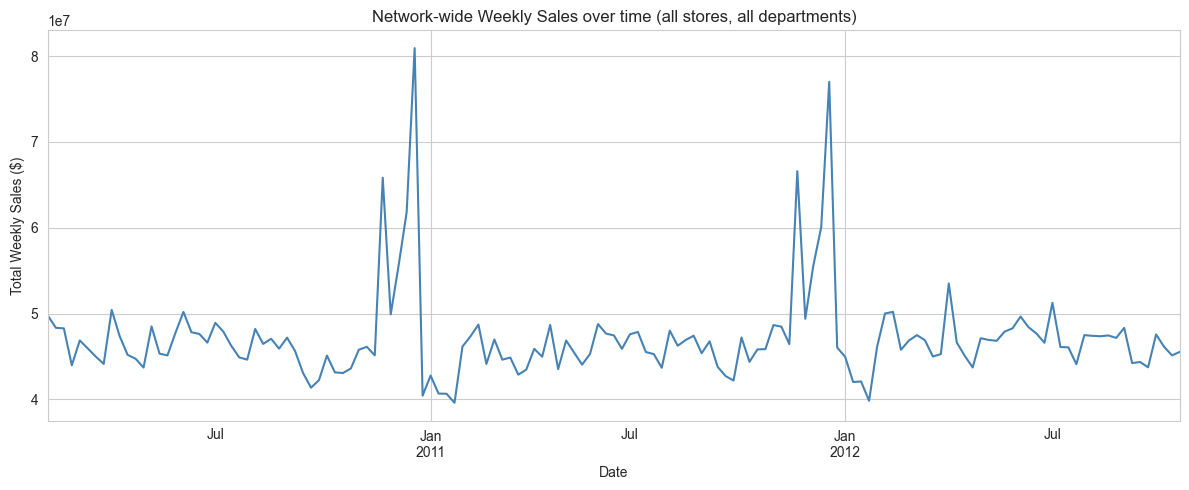

In [39]:
# .groupby('Date')['Weekly_Sales'].sum() collapses the table to one total-sales value per week.
network_sales_by_week = df.groupby('Date')['Weekly_Sales'].sum()

fig, ax = plt.subplots(figsize=(12, 5))
network_sales_by_week.plot(ax=ax, color='steelblue')
ax.set_title('Network-wide Weekly Sales over time (all stores, all departments)')
ax.set_xlabel('Date')
ax.set_ylabel('Total Weekly Sales ($)')
plt.tight_layout()
plt.show()


### 📝 What we learned (Step 6)
- Row counts are fairly balanced across stores but uneven across departments — not every department exists in every store.
- `Type` A stores are the most common; B is second; C is the smallest group.
- `Weekly_Sales` is heavily right-skewed with a long tail of holiday/flagship-department spikes — medians will often tell a cleaner story than means.
- The network-wide sales line shows a clear late-November and late-December spike in each of the years covered.


## Step 7 — Bivariate EDA

Now we compare pairs of variables to see how they relate. These are **descriptive** views only — we are not running significance tests or fitting models.


### 7a. `Weekly_Sales` by store `Type`

**What**: boxplot of `Weekly_Sales` split by `Type` (A/B/C).
**Why**: store format is a natural segmentation variable; peers should be compared within type.
**Note**: we use a symlog y-axis because `Weekly_Sales` has such a wide range that a linear axis would compress most of the boxes into invisibility.


C:\Users\betoq\AppData\Local\Temp\ipykernel_11104\1822318817.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Type', y='Weekly_Sales', order=['A', 'B', 'C'],


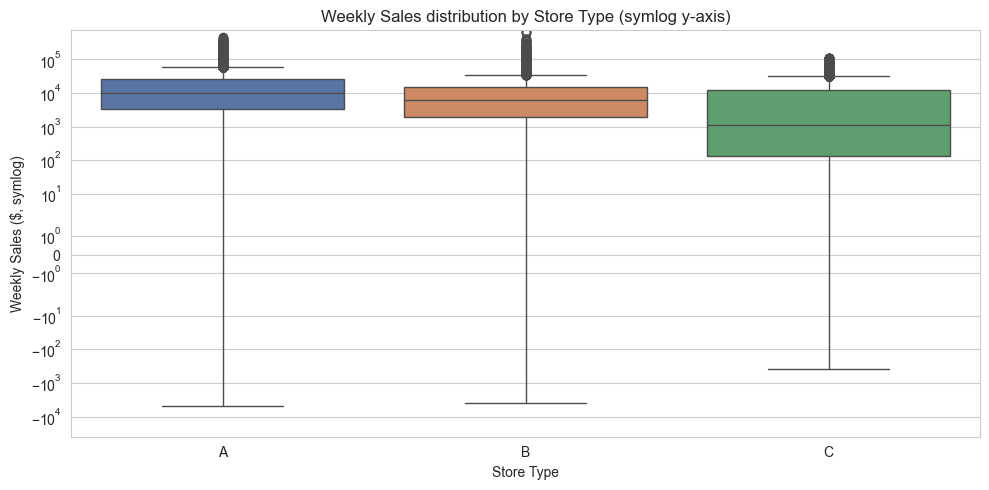

Mean & median Weekly_Sales by Type:
          mean    median   count
Type                            
A    20,099.57 10,105.17  215478
B    12,237.08  6,187.87  163495
C     9,519.53  1,149.67   42597


In [40]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='Type', y='Weekly_Sales', order=['A', 'B', 'C'],
            palette=['#4C72B0', '#DD8452', '#55A868'], ax=ax)
ax.set_yscale('symlog')   # symmetric log scale handles the negative and the large positives
ax.set_title('Weekly Sales distribution by Store Type (symlog y-axis)')
ax.set_xlabel('Store Type')
ax.set_ylabel('Weekly Sales ($, symlog)')
plt.tight_layout()
plt.show()

print('Mean & median Weekly_Sales by Type:')
# .agg(['mean','median']) computes both statistics in one call
print(df.groupby('Type', observed=True)['Weekly_Sales'].agg(['mean', 'median', 'count']))


### 7b. `Weekly_Sales` by `IsHoliday`

**What**: boxplot and simple mean comparison of holiday vs. non-holiday weeks.
**Why**: are holiday weeks actually bigger? We are **not** running a t-test here — just looking.


C:\Users\betoq\AppData\Local\Temp\ipykernel_11104\1067715095.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='IsHoliday', y='Weekly_Sales', palette=['#4C72B0', '#C44E52'], ax=ax)


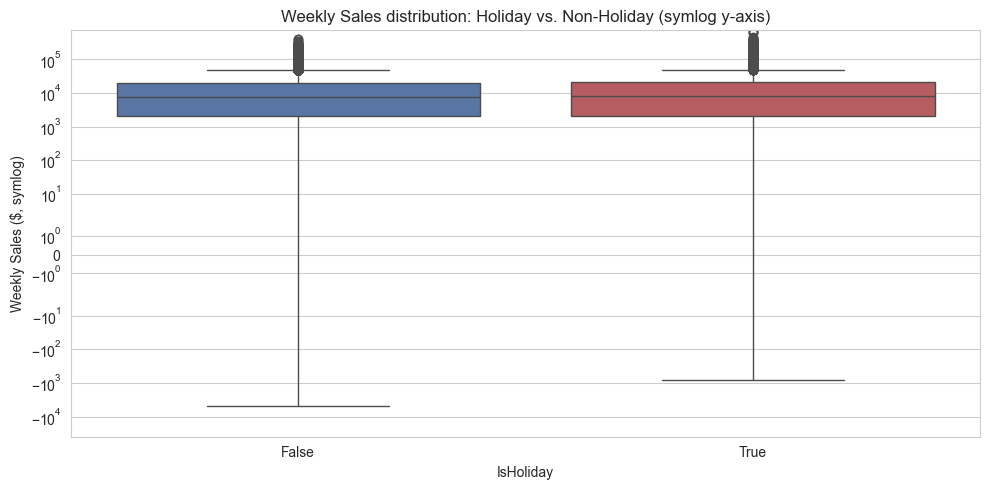

Mean & median Weekly_Sales by IsHoliday:
               mean   median   count
IsHoliday                           
False     15,901.45 7,589.95  391909
True      17,035.82 7,947.74   29661


In [41]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='IsHoliday', y='Weekly_Sales', palette=['#4C72B0', '#C44E52'], ax=ax)
ax.set_yscale('symlog')
ax.set_title('Weekly Sales distribution: Holiday vs. Non-Holiday (symlog y-axis)')
ax.set_xlabel('IsHoliday')
ax.set_ylabel('Weekly Sales ($, symlog)')
plt.tight_layout()
plt.show()

print('Mean & median Weekly_Sales by IsHoliday:')
print(df.groupby('IsHoliday')['Weekly_Sales'].agg(['mean', 'median', 'count']))


### 7c. `Weekly_Sales` vs. `Size`

**What**: scatter of per-store total annual sales against store Size.
**Why**: a single scatter of the 421K raw rows would be unreadable. Aggregating to one point per store shows the relationship we actually care about.


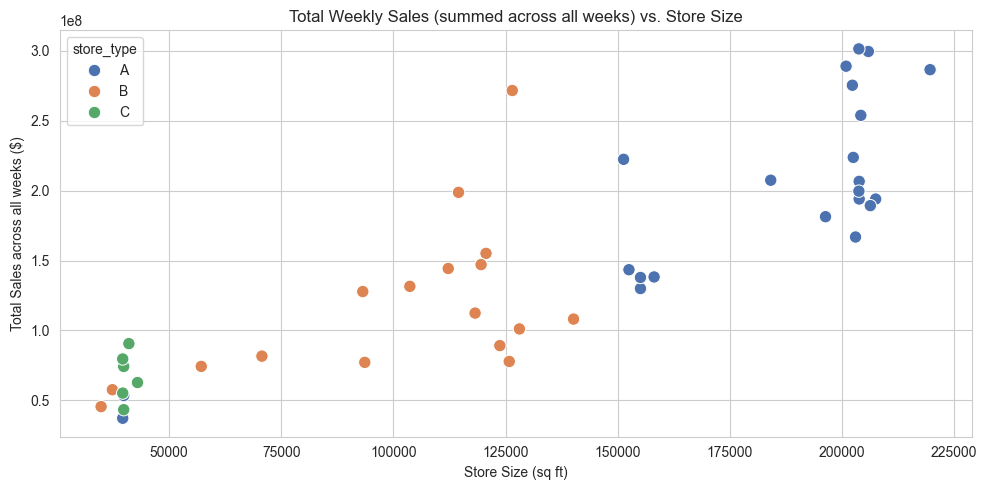

,Store,total_sales,size,store_type
0,1,"222,402,808.85",151315,A
1,2,"275,382,440.98",202307,A
2,3,"57,586,735.07",37392,B
3,4,"299,543,953.38",205863,A
4,5,"45,475,688.90",34875,B


In [42]:
# Collapse to one row per store with (Size, total Weekly_Sales, Type)
per_store = (
    df.groupby('Store', as_index=False)
      .agg(total_sales=('Weekly_Sales', 'sum'),
           size=('Size', 'first'),
           store_type=('Type', 'first'))
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(data=per_store, x='size', y='total_sales', hue='store_type',
                palette=['#4C72B0', '#DD8452', '#55A868'], s=80, ax=ax)
ax.set_title('Total Weekly Sales (summed across all weeks) vs. Store Size')
ax.set_xlabel('Store Size (sq ft)')
ax.set_ylabel('Total Sales across all weeks ($)')
plt.tight_layout()
plt.show()

per_store.head()


### 7d. Correlation heatmap

**What**: Pearson correlation between the numeric variables in the merged table.
**Why**: a quick read on which variables move together. **What correlation does NOT tell us**: causation, non-linear relationships, or anything about thresholds. A correlation near zero can still hide a strong non-linear pattern.


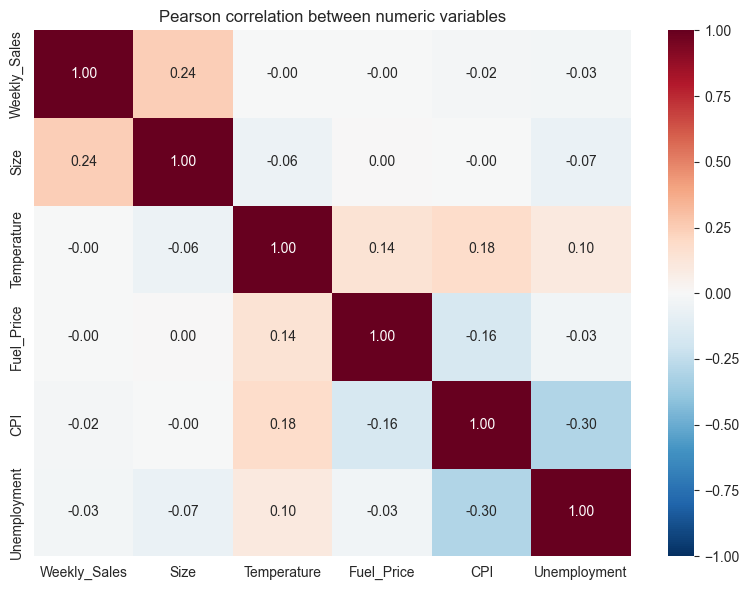

              Weekly_Sales  Size  Temperature  Fuel_Price   CPI  Unemployment
Weekly_Sales          1.00  0.24        -0.00       -0.00 -0.02         -0.03
Size                  0.24  1.00        -0.06        0.00 -0.00         -0.07
Temperature          -0.00 -0.06         1.00        0.14  0.18          0.10
Fuel_Price           -0.00  0.00         0.14        1.00 -0.16         -0.03
CPI                  -0.02 -0.00         0.18       -0.16  1.00         -0.30
Unemployment         -0.03 -0.07         0.10       -0.03 -0.30          1.00


In [43]:
corr_cols = ['Weekly_Sales', 'Size', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
# .corr() defaults to Pearson; returns a correlation matrix.
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
# sns.heatmap draws a color-coded matrix; annot=True writes the numbers on the tiles.
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Pearson correlation between numeric variables')
plt.tight_layout()
plt.show()

print(corr.round(2))


### 7e. Monthly seasonality of network-wide sales

**What**: aggregate total network sales by calendar month-of-year across all years in the data.
**Why**: confirms the holiday pattern we saw in the weekly chart and gives a seasonal-index view.


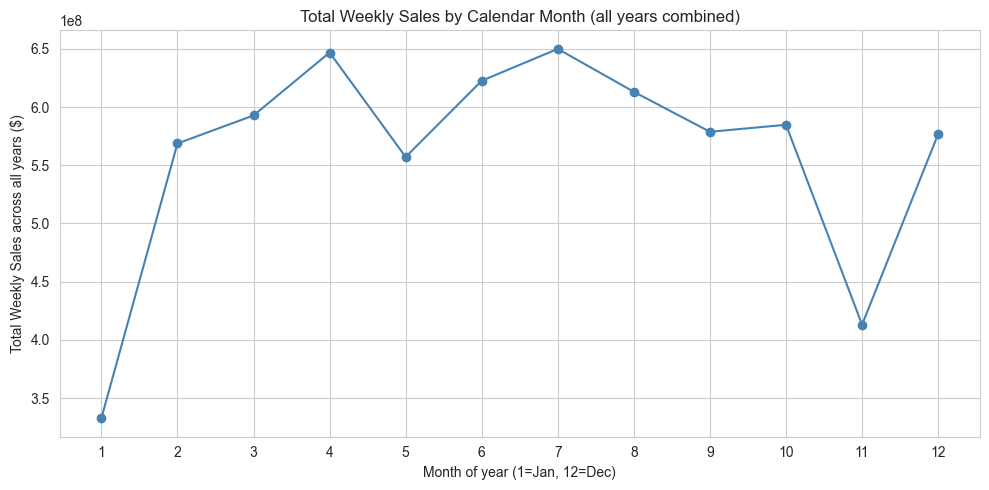

month
1    332,598,438.49
2    568,727,890.45
3    592,785,901.28
4    646,859,784.97
5    557,125,571.95
6    622,629,886.84
7    650,000,977.25
8    613,090,208.82
9    578,761,179.26
10   584,784,787.59
11   413,015,725.01
12   576,838,635.20
Name: Weekly_Sales, dtype: float64


In [44]:
# .dt.month extracts the month (1..12) from a datetime column
monthly_totals = (
    df.assign(month=df['Date'].dt.month)
      .groupby('month')['Weekly_Sales']
      .sum()
)

fig, ax = plt.subplots(figsize=(10, 5))
monthly_totals.plot(kind='line', marker='o', ax=ax, color='steelblue')
ax.set_title('Total Weekly Sales by Calendar Month (all years combined)')
ax.set_xlabel('Month of year (1=Jan, 12=Dec)')
ax.set_ylabel('Total Weekly Sales across all years ($)')
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

print(monthly_totals)


### 📝 What we learned (Step 7)
- `Type` A stores have systematically larger `Weekly_Sales` than B, which are larger than C — matching their `Size`.
- Holiday weeks have higher mean sales than non-holiday weeks, but the distributions overlap heavily.
- Store `Size` is strongly related to total annual sales; `Type` A stores cluster in the high-`Size` / high-sales region.
- Correlations between `Weekly_Sales` and the macro variables (`CPI`, `Fuel_Price`, `Unemployment`, `Temperature`) are weak when measured on raw weekly rows.
- Monthly seasonality confirms a big November–December peak; the rest of the year is relatively flat.


## Step 8 — Quick look at Store 10 (descriptive only)

A first orientation to the store we will eventually evaluate. **No peer comparisons, no rankings, no verdicts here** — that is the next notebook's job.


In [45]:
STORE_ID = 10
store10 = df[df['Store'] == STORE_ID].copy()

print(f'Store {STORE_ID} overview')
print('-' * 40)
print(f"Type         : {store10['Type'].iloc[0]}")
print(f"Size (sq ft) : {store10['Size'].iloc[0]:,}")
print(f"# departments: {store10['Dept'].nunique()}")
print(f"Date range   : {store10['Date'].min().date()}  →  {store10['Date'].max().date()}")
print(f"# rows       : {len(store10):,}")
print(f"Total sales  : ${store10['Weekly_Sales'].sum():,.0f}")


Store 10 overview
----------------------------------------
Type         : B
Size (sq ft) : 126,512
# departments: 77
Date range   : 2010-02-05  →  2012-10-26
# rows       : 10,315
Total sales  : $271,617,714


### 8a. Store 10 weekly sales over time

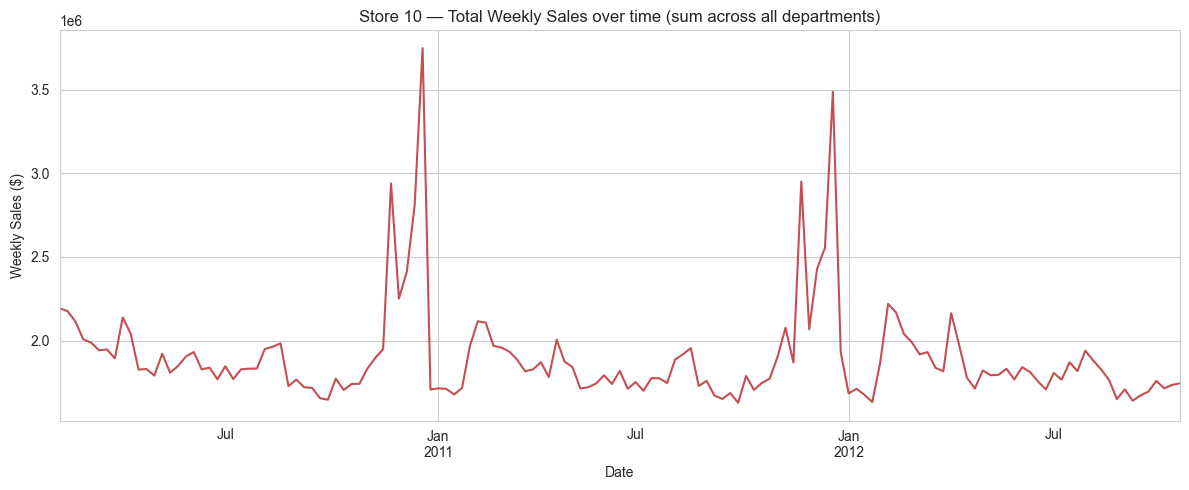

In [46]:
store10_weekly = store10.groupby('Date')['Weekly_Sales'].sum()

fig, ax = plt.subplots(figsize=(12, 5))
store10_weekly.plot(ax=ax, color='#C44E52')
ax.set_title(f'Store {STORE_ID} — Total Weekly Sales over time (sum across all departments)')
ax.set_xlabel('Date')
ax.set_ylabel('Weekly Sales ($)')
plt.tight_layout()
plt.show()


### 8b. Store 10 — top 5 departments by total revenue

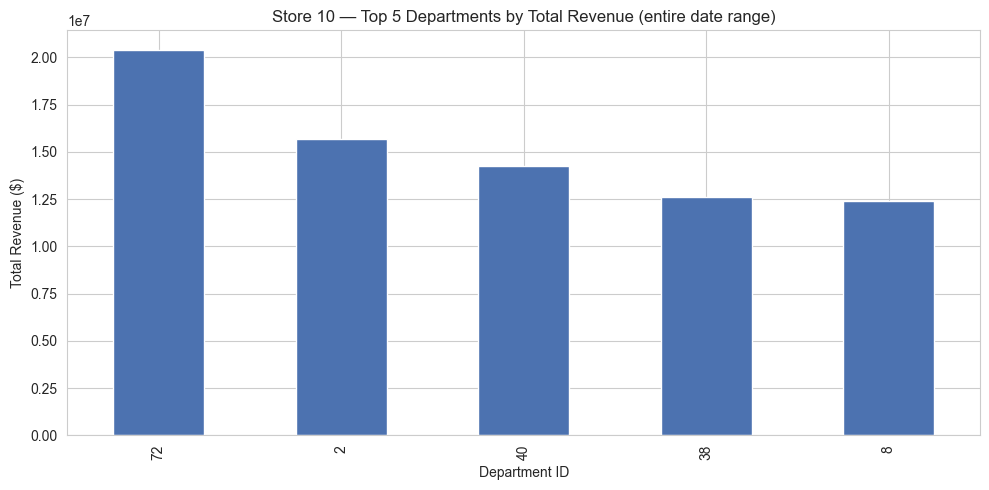

Dept
72    $20,410,927
2     $15,700,727
40    $14,280,921
38    $12,593,725
8     $12,403,798
Name: Weekly_Sales, dtype: str


In [47]:
top5_depts = (
    store10.groupby('Dept')['Weekly_Sales']
           .sum()
           .sort_values(ascending=False)
           .head(5)
)

fig, ax = plt.subplots(figsize=(10, 5))
top5_depts.plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_title(f'Store {STORE_ID} — Top 5 Departments by Total Revenue (entire date range)')
ax.set_xlabel('Department ID')
ax.set_ylabel('Total Revenue ($)')
plt.tight_layout()
plt.show()

print(top5_depts.apply(lambda x: f'${x:,.0f}'))


### 📝 What we learned (Step 8)
- Store 10 is one specific store in the network — we now know its type, size, number of departments, and time coverage.
- Its weekly-sales curve shows the expected holiday peaks; whether its overall level is rising, flat, or falling relative to peers is a question for the next notebook.
- Revenue is concentrated in a handful of departments — a familiar Pareto pattern.


## Step 9 — Wrap-up: Data dictionary & open questions

### Mini data dictionary — merged table `df`

| Column | Dtype | Meaning |
|---|---|---|
| `Store` | int | Anonymized store ID (1–45). |
| `Dept` | int | Anonymized department ID within a store. |
| `Date` | datetime64 | Week-ending date (weekly granularity). |
| `Weekly_Sales` | float | Revenue for that (Store, Dept, Week). May be negative in rare return-heavy weeks. |
| `IsHoliday` | bool | True if the week includes one of the four tracked holidays (Super Bowl, Labor Day, Thanksgiving, Christmas). |
| `is_negative_sale` | bool | Flag we added: `Weekly_Sales < 0`. |
| `is_outlier_iqr` | bool | Flag we added: row falls outside the 1.5·IQR bounds. |
| `Type` | category | Store format: A (largest), B, C (smallest). |
| `Size` | int | Store floor area in sq ft. |
| `Temperature` | float | Average regional temperature that week (°F). |
| `Fuel_Price` | float | Average regional fuel price that week ($/gal). |
| `MarkDown1..5` | float | Anonymized promotional markdowns. ~60%+ missing (started partway through the series). |
| `CPI` | float | Regional Consumer Price Index for that week. |
| `Unemployment` | float | Regional unemployment rate for that week (%). |

### Open questions surfaced by this EDA (for the next notebook)

1. **Peer benchmarking** — Is Store 10's weekly-sales level above, at, or below the median of its same-Type peers? The raw curve alone cannot answer this.
2. **Trend direction** — Over the 2010–2012 window, is Store 10 growing, flat, or declining in same-week-year-over-year terms? A trend line decomposed from seasonality would clarify.
3. **Holiday lift** — Do holidays produce the same *proportional* lift at Store 10 as at similar stores, or is it under/over-indexing on holiday weeks specifically?
4. **Department mix** — Is Store 10's top-5-department mix representative of its type, or is one specific department carrying its results?
5. **Macro sensitivity** — Given the weak raw correlations with CPI/Fuel_Price/Unemployment, does any macro variable matter *at the store level* once we control for seasonality?

These questions define the next notebook. We end this one here.
